In [1]:
from pathlib import Path
import json
import numpy as np

NORMALIZED_SAVE_DIR = Path("/home/gella.saikrishna/code/Manual/saved_sleep_edf/normalized_psg")


def load_normalized_from_disk(load_path):
    saved = np.load(load_path, allow_pickle=True)

    metadata = json.loads(str(saved["metadata"].item()))
    hypnogram = saved["hypnogram"]

    if len(hypnogram) == 0:
        hypnogram = None

    participant = metadata["participant"]
    day = metadata["day"]
    key = (participant, day)

    psg_entry = {
        "participant": participant,
        "day": day,
        "psg_file": metadata["psg_file"],
        "channel_names": metadata["channel_names"],
        "sfreq": metadata["sfreq"],
        "normalized_data": saved["normalized_data"],
    }

    stats_entry = metadata.get("stats", {})

    hypno_entry = {
        "participant": participant,
        "day": day,
        "hypnogram_file": metadata.get("hypnogram_file"),
        "hypnogram": hypnogram,
    }

    return key, psg_entry, stats_entry, hypno_entry


normalized_psg_data = {}
psg_normalization_stats = {}
hypnogram_data = {}

saved_files = sorted(NORMALIZED_SAVE_DIR.glob("*.npz"))

print(f"Saved normalized PSG files found: {len(saved_files)}")

if len(saved_files) == 0:
    raise FileNotFoundError(f"No saved normalized files found in {NORMALIZED_SAVE_DIR}")

for load_path in saved_files:
    key, psg_entry, stats_entry, hypno_entry = load_normalized_from_disk(load_path)

    normalized_psg_data[key] = psg_entry
    psg_normalization_stats[key] = stats_entry
    hypnogram_data[key] = hypno_entry

print(f"Loaded normalized PSG files: {len(normalized_psg_data)}")
print(f"Loaded hypnograms: {len(hypnogram_data)}")

Saved normalized PSG files found: 153
Loaded normalized PSG files: 153
Loaded hypnograms: 153


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
import numpy as np


def normalize_single_psg_file(raw):
    """
    Normalize one PSG file independently.

    MNE loads EDF signal values in volts.
    This function converts them to microvolts first, then normalizes
    each channel separately using that channel's full-night mean and std.

    Hypnograms are not used or changed here.
    """

    data_uv = raw.get_data() * 1e6
    normalized_data = np.zeros_like(data_uv, dtype=np.float32)

    stats = {}

    for ch_idx, ch_name in enumerate(raw.ch_names):
        signal_uv = data_uv[ch_idx]

        mean_uv = np.mean(signal_uv)
        std_uv = np.std(signal_uv)

        if std_uv == 0 or not np.isfinite(std_uv):
            normalized_signal = np.zeros_like(signal_uv, dtype=np.float32)
        else:
            normalized_signal = ((signal_uv - mean_uv) / std_uv).astype(np.float32)

        normalized_data[ch_idx] = normalized_signal

        stats[ch_name] = {
            "original_mean_uv": float(mean_uv),
            "original_std_uv": float(std_uv),
            "original_min_uv": float(np.min(signal_uv)),
            "original_max_uv": float(np.max(signal_uv)),
            "normalized_mean": float(np.mean(normalized_signal)),
            "normalized_std": float(np.std(normalized_signal)),
            "normalized_min": float(np.min(normalized_signal)),
            "normalized_max": float(np.max(normalized_signal)),
        }

    return normalized_data, stats

In [4]:
from sklearn.model_selection import train_test_split

test_size = 0.2
random_state = 42

all_participants = sorted(set(key[0] for key in normalized_psg_data.keys()))

train_participants, test_participants = train_test_split(
    all_participants,
    test_size=test_size,
    random_state=random_state,
    shuffle=True,
)

train_participants = sorted(train_participants)
test_participants = sorted(test_participants)

print(f"Total participants: {len(all_participants)}")
print(f"Train participants: {len(train_participants)}")
print(f"Test participants: {len(test_participants)}")

print("\nTrain participants:")
print(train_participants)

print("\nTest participants:")
print(test_participants)

Total participants: 78
Train participants: 62
Test participants: 16

Train participants:
['SC401', 'SC402', 'SC403', 'SC405', 'SC406', 'SC407', 'SC408', 'SC409', 'SC411', 'SC413', 'SC414', 'SC415', 'SC416', 'SC417', 'SC419', 'SC420', 'SC421', 'SC423', 'SC424', 'SC425', 'SC426', 'SC427', 'SC428', 'SC429', 'SC431', 'SC432', 'SC435', 'SC436', 'SC437', 'SC438', 'SC440', 'SC441', 'SC442', 'SC443', 'SC444', 'SC446', 'SC447', 'SC448', 'SC449', 'SC451', 'SC452', 'SC453', 'SC454', 'SC456', 'SC457', 'SC458', 'SC459', 'SC460', 'SC461', 'SC463', 'SC464', 'SC465', 'SC466', 'SC470', 'SC471', 'SC472', 'SC473', 'SC474', 'SC476', 'SC477', 'SC480', 'SC481']

Test participants:
['SC400', 'SC404', 'SC410', 'SC412', 'SC418', 'SC422', 'SC430', 'SC433', 'SC434', 'SC445', 'SC450', 'SC455', 'SC462', 'SC467', 'SC475', 'SC482']


In [23]:
fine_tuning_size = 0.20

fine_tuning_participants, _ = train_test_split(
    train_participants,
    train_size=fine_tuning_size,
    random_state=random_state,
    shuffle=True,
)

fine_tuning_participants = sorted(fine_tuning_participants)

print(f"\nFine tuning participants: {len(fine_tuning_participants)}")
print(fine_tuning_participants)


Fine tuning participants: 12
['SC409', 'SC414', 'SC419', 'SC424', 'SC426', 'SC428', 'SC437', 'SC449', 'SC454', 'SC465', 'SC480', 'SC481']


In [6]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=7,
            stride=1,
            padding=3,
            bias=False,
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.dropout = nn.Dropout(dropout)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + residual
        out = F.relu(out)

        return out

class SleepResNet1D(nn.Module):
    def __init__(self, n_channels=3, n_classes=6, dropout=0.2, embedding_dim=512):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = nn.Sequential(
            ResidualBlock1D(64, 64, stride=1, dropout=dropout),
            ResidualBlock1D(64, 64, stride=1, dropout=dropout),
        )

        self.layer2 = nn.Sequential(
            ResidualBlock1D(64, 128, stride=2, dropout=dropout),
            ResidualBlock1D(128, 128, stride=1, dropout=dropout),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock1D(128, 256, stride=2, dropout=dropout),
            ResidualBlock1D(256, 256, stride=1, dropout=dropout),
        )

        self.layer4 = nn.Sequential(
            ResidualBlock1D(256, 512, stride=2, dropout=dropout),
            ResidualBlock1D(512, 512, stride=1, dropout=dropout),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.projection_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, n_classes),
        )

    def encode(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return x

    def get_embedding(self, x):
        features = self.encode(x)
        embeddings = self.projection_head(features)
        embeddings = F.normalize(embeddings, dim=1)
        return embeddings

    def forward(self, x):
        features = self.encode(x)
        logits = self.classifier(features)
        return logits

In [7]:
def augment_epoch(x):
    """
    x shape: [channels, time]
    """

    x = x.clone()

    # Add small Gaussian noise
    if torch.rand(1).item() < 0.5:
        noise = torch.randn_like(x) * 0.02
        x = x + noise

    # Random scaling
    if torch.rand(1).item() < 0.5:
        scale = torch.empty(1).uniform_(0.8, 1.2).item()
        x = x * scale

    # Random time masking
    if torch.rand(1).item() < 0.5:
        time_len = x.shape[-1]
        mask_len = int(time_len * 0.05)
        start = torch.randint(0, time_len - mask_len, (1,)).item()
        x[:, start:start + mask_len] = 0

    return x

In [8]:
class ContrastiveSleepDataset(Dataset):
    def __init__(
        self,
        data_dict,
        participants,
        data_key="normalized_data",
        epoch_seconds=30,
        selected_channels=None,
    ):
        self.samples = []

        for key, value in data_dict.items():
            participant_id = key[0]

            if participant_id not in participants:
                continue

            signal = torch.tensor(value[data_key], dtype=torch.float32)
            sfreq = value["sfreq"]

            # Make sure signal is [channels, time]
            if signal.ndim == 2 and signal.shape[0] > signal.shape[1]:
                signal = signal.T

            # Keep only selected channels, e.g. 2 EEG + 1 EMG
            if selected_channels is not None:
                signal = signal[selected_channels, :]

            epoch_length = int(epoch_seconds * sfreq)
            total_samples = signal.shape[1]
            n_epochs = total_samples // epoch_length

            for i in range(n_epochs):
                start = i * epoch_length
                end = start + epoch_length
                epoch = signal[:, start:end]
                self.samples.append(epoch)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        epoch = self.samples[idx]

        view_1 = augment_epoch(epoch)
        view_2 = augment_epoch(epoch)

        return view_1, view_2

In [9]:
selected_channels = [0, 1, 4]  # change this based on your channel_names output

pretrain_dataset = ContrastiveSleepDataset(
    normalized_psg_data,
    train_participants,
    data_key="normalized_data",
    epoch_seconds=30,
    selected_channels=selected_channels
)

x1, x2 = pretrain_dataset[0]
print(x1.shape)

torch.Size([3, 3000])


In [10]:
class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        z = torch.cat([z1, z2], dim=0)
        similarity = torch.matmul(z, z.T) / self.temperature

        mask = torch.eye(2 * batch_size, device=z.device).bool()
        similarity = similarity.masked_fill(mask, -1e9)

        positives = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        loss = F.cross_entropy(similarity, positives)
        return loss

In [11]:
class SupervisedSleepDataset(Dataset):
    def __init__(
        self,
        data_dict,
        hypno_dict,
        participants,
        data_key="normalized_data",
        epoch_seconds=30,
        selected_channels=None,
    ):
        self.samples = []
        self.labels = []

        for key, value in data_dict.items():
            participant_id = key[0]

            if participant_id not in participants:
                continue

            # Ensure matching hypnogram is present
            if key not in hypno_dict or hypno_dict[key]["hypnogram"] is None:
                continue

            signal = torch.tensor(value[data_key], dtype=torch.float32)
            sfreq = value["sfreq"]
            hypnogram = hypno_dict[key]["hypnogram"]

            # Make sure signal is [channels, time]
            if signal.ndim == 2 and signal.shape[0] > signal.shape[1]:
                signal = signal.T

            if selected_channels is not None:
                signal = signal[selected_channels, :]

            epoch_length = int(epoch_seconds * sfreq)
            total_samples = signal.shape[1]
            n_epochs = min(total_samples // epoch_length, len(hypnogram))

            for i in range(n_epochs):
                start = i * epoch_length
                end = start + epoch_length
                epoch_data = signal[:, start:end]
                
                # Filter out unscored or invalid stages if your dataset uses negative values for them
                label = int(hypnogram[i])
                if label >= 0 and label < 6:  # Matching SleepResNet1D n_classes=6
                    self.samples.append(epoch_data)
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [12]:
class SupervisedSleepDataset(Dataset):
    def __init__(
        self,
        data_dict,
        hypno_dict,
        participants,
        data_key="normalized_data",
        epoch_seconds=30,
        selected_channels=None,
    ):
        self.samples = []
        self.labels = []

        for key, value in data_dict.items():
            participant_id = key[0]

            if participant_id not in participants:
                continue

            # Ensure matching hypnogram is present
            if key not in hypno_dict or hypno_dict[key]["hypnogram"] is None:
                continue

            signal = torch.tensor(value[data_key], dtype=torch.float32)
            sfreq = value["sfreq"]
            hypnogram = hypno_dict[key]["hypnogram"]

            # Make sure signal is [channels, time]
            if signal.ndim == 2 and signal.shape[0] > signal.shape[1]:
                signal = signal.T

            if selected_channels is not None:
                signal = signal[selected_channels, :]

            epoch_length = int(epoch_seconds * sfreq)
            total_samples = signal.shape[1]
            n_epochs = min(total_samples // epoch_length, len(hypnogram))

            for i in range(n_epochs):
                start = i * epoch_length
                end = start + epoch_length
                epoch_data = signal[:, start:end]
                
                # Filter out unscored or invalid stages if your dataset uses negative values for them
                label = int(hypnogram[i])
                if label >= 0 and label < 6:  # Matching SleepResNet1D n_classes=6
                    self.samples.append(epoch_data)
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [16]:
import os
import torch
import torch.nn as nn
from pathlib import Path  # Ensure Path is explicitly imported
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 0. BASE DIRECTORY SETTING
# ==========================================
# Defining checkpoint_dir explicitly as a Path object to prevent 
# "unsupported operand type(s) for /: 'str' and 'str'" errors.
checkpoint_dir = Path("pretraining_checkpoints")

# ==========================================
# 1. DATA LOADER SETUP
# ==========================================
# Re-using fine_tuning_participants and test_participants from your notebook split
finetune_dataset = SupervisedSleepDataset(
    normalized_psg_data,
    hypnogram_data,
    fine_tuning_participants,
    data_key="normalized_data",
    epoch_seconds=30,
    selected_channels=selected_channels
)

test_dataset = SupervisedSleepDataset(
    normalized_psg_data,
    hypnogram_data,
    test_participants,
    data_key="normalized_data",
    epoch_seconds=30,
    selected_channels=selected_channels
)

finetune_loader = DataLoader(finetune_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Fine-tuning dataset size: {len(finetune_dataset)} samples")
print(f"Testing dataset size: {len(test_dataset)} samples")

# ==========================================
# 2. MODEL INITIALIZATION & PRETRAIN LOADING
# ==========================================
finetune_checkpoint_dir = Path("finetuning_checkpoints")
finetune_checkpoint_dir.mkdir(exist_ok=True)

# Instantiating SleepResNet1D exactly as defined
model = SleepResNet1D(
    n_channels=3,
    n_classes=6,
    dropout=0.2,
    embedding_dim=512
).to(device)

# Path combining syntax works perfectly now because checkpoint_dir is a Path object
pretrained_path = checkpoint_dir / "best_pretrain_model.pt"

if pretrained_path.exists():
    print(f"Loading weights from pretraining checkpoint: {pretrained_path}")
    pretrained_checkpoint = torch.load(pretrained_path, map_location=device)
    
    # Safely extract state dict whether it is a raw dictionary or wrapped checkpoint structure
    if isinstance(pretrained_checkpoint, dict) and "model_state_dict" in pretrained_checkpoint:
        model.load_state_dict(pretrained_checkpoint["model_state_dict"])
    else:
        model.load_state_dict(pretrained_checkpoint)
else:
    print(f"⚠️ Warning: {pretrained_path} not found! Training architecture from scratch.")

# ==========================================
# 3. SUPERVISED FINE-TUNING LOOP
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

finetune_epochs = 30
best_ft_loss = float("inf")

print("\n" + "="*60)
print("STARTING SUPERVISED FINE-TUNING")
print("="*60)

for epoch in range(finetune_epochs):
    model.train()
    total_loss = 0
    
    for inputs, labels in finetune_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Supervised linear head mapping via forward()
        logits = model(inputs)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_ft_loss = total_loss / len(finetune_loader)
    print(f"Fine-Tuning Epoch [{epoch+1}/{finetune_epochs}], Loss: {avg_ft_loss:.4f}")
    
    # Checkpoint structural state tracking
    ft_checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": avg_ft_loss,
    }
    
    # Save periodic epoch files
    if (epoch + 1) % 5 == 0:
        epoch_path = finetune_checkpoint_dir / f"finetune_epoch_{epoch+1}.pt"
        torch.save(ft_checkpoint, epoch_path)
        print(f"  Saved fine-tuning checkpoint: {epoch_path}")
        
    # Save optimal best model validation weights
    if avg_ft_loss < best_ft_loss:
        best_ft_loss = avg_ft_loss
        best_ft_path = finetune_checkpoint_dir / "best_finetune_model.pt"
        torch.save(ft_checkpoint, best_ft_path)
        print(f"  ✓ Saved best fine-tuned model (loss: {best_ft_loss:.4f}): {best_ft_path}")

print("\n" + "="*60)
print("FINE-TUNING COMPLETE")
print("="*60)

# ==========================================
# 4. EVALUATION & ACCURACY OUTPUT
# ==========================================
# Load structural state back from optimal fine-tune point path
best_finetune_path = finetune_checkpoint_dir / "best_finetune_model.pt"
best_model_checkpoint = torch.load(best_finetune_path, map_location=device)
model.load_state_dict(best_model_checkpoint["model_state_dict"])
model.eval()

all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        logits = model(inputs)
        _, preds = torch.max(logits, dim=1)
        
        all_predictions.extend(preds.cpu().numpy())
        all_ground_truths.extend(labels.numpy())

# Final Output display metrics
test_accuracy = accuracy_score(all_ground_truths, all_predictions)
print("\n" + "="*60)
print("FINAL TEST PERFORMANCE METRICS")
print("="*60)
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("Detailed Classification Analysis:")
print(classification_report(
    all_ground_truths, 
    all_predictions, 
    target_names=[f"Stage {i}" for i in sorted(list(set(all_ground_truths)))]
))

Fine-tuning dataset size: 31886 samples
Testing dataset size: 87391 samples
Loading weights from pretraining checkpoint: pretraining_checkpoints/best_pretrain_model.pt

STARTING SUPERVISED FINE-TUNING
Fine-Tuning Epoch [1/30], Loss: 0.4186
  ✓ Saved best fine-tuned model (loss: 0.4186): finetuning_checkpoints/best_finetune_model.pt
Fine-Tuning Epoch [2/30], Loss: 0.2535
  ✓ Saved best fine-tuned model (loss: 0.2535): finetuning_checkpoints/best_finetune_model.pt
Fine-Tuning Epoch [3/30], Loss: 0.2275
  ✓ Saved best fine-tuned model (loss: 0.2275): finetuning_checkpoints/best_finetune_model.pt
Fine-Tuning Epoch [4/30], Loss: 0.2150
  ✓ Saved best fine-tuned model (loss: 0.2150): finetuning_checkpoints/best_finetune_model.pt
Fine-Tuning Epoch [5/30], Loss: 0.2048
  Saved fine-tuning checkpoint: finetuning_checkpoints/finetune_epoch_5.pt
  ✓ Saved best fine-tuned model (loss: 0.2048): finetuning_checkpoints/best_finetune_model.pt
Fine-Tuning Epoch [6/30], Loss: 0.1944
  ✓ Saved best fine-

In [26]:
finetune_checkpoint_dir = Path("finetuning_checkpoints")
finetune_checkpoint_dir.mkdir(exist_ok=True)   # <-- ADD THIS LINE

In [28]:
def get_latest_checkpoint(checkpoint_dir, prefix="finetune_epoch_"):
    """Return the path of the latest checkpoint file (by epoch number)."""
    checkpoint_files = list(checkpoint_dir.glob(f"{prefix}*.pt"))
    if not checkpoint_files:
        return None
    epochs = [int(f.stem.split("_")[-1]) for f in checkpoint_files]
    latest_idx = epochs.index(max(epochs))
    return checkpoint_files[latest_idx]

# ==========================================
# 3. SUPERVISED FINE-TUNING LOOP (RESUMABLE + EARLY STOPPING)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# New total number of epochs desired (maximum)
TOTAL_EPOCHS = 50

# Early stopping parameters
patience = 5
min_delta = 0.001
best_loss = float('inf')
wait = 0

# Try to resume from the latest checkpoint
latest_checkpoint = get_latest_checkpoint(finetune_checkpoint_dir)
start_epoch = 0
best_ft_loss = float("inf")   # for saving best model based on loss

if latest_checkpoint is not None:
    print(f"Resuming from checkpoint: {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]  # last completed epoch
    best_ft_loss = checkpoint.get("best_loss", float("inf"))
    # Restore early stopping state if saved (optional)
    best_loss = checkpoint.get("best_early_stop_loss", float("inf"))
    wait = checkpoint.get("wait_count", 0)
    print(f"Resuming from epoch {start_epoch}, early stopping wait count: {wait}")
else:
    print("No checkpoint found. Starting from scratch.")

print("\n" + "="*60)
print(f"STARTING SUPERVISED FINE-TUNING (epochs {start_epoch+1} to {TOTAL_EPOCHS})")
print("="*60)

for epoch in range(start_epoch, TOTAL_EPOCHS):
    model.train()
    total_loss = 0
    
    for inputs, labels in finetune_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        logits = model(inputs)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_ft_loss = total_loss / len(finetune_loader)
    print(f"Fine-Tuning Epoch [{epoch+1}/{TOTAL_EPOCHS}], Loss: {avg_ft_loss:.4f}")
    
    # ---------- Early Stopping Check (based on training loss) ----------
    if avg_ft_loss < best_loss - min_delta:
        best_loss = avg_ft_loss
        wait = 0
        # (Optional: print improvement message)
    else:
        wait += 1
        print(f"  No improvement for {wait} epoch(s) (best: {best_loss:.4f})")
        if wait >= patience:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}. No improvement for {patience} epochs.")
            break   # exit the training loop
    
    # ---------- Save checkpoint every 5 epochs ----------
    if (epoch + 1) % 5 == 0:
        ft_checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_ft_loss,
            "best_loss": best_ft_loss,
            # Save early stopping state to allow resuming later
            "best_early_stop_loss": best_loss,
            "wait_count": wait,
        }
        epoch_path = finetune_checkpoint_dir / f"finetune_epoch_{epoch+1}.pt"
        torch.save(ft_checkpoint, epoch_path)
        print(f"  Saved checkpoint: {epoch_path}")
        
    # ---------- Save best model based on training loss ----------
    if avg_ft_loss < best_ft_loss:
        best_ft_loss = avg_ft_loss
        best_ft_path = finetune_checkpoint_dir / "best_finetune_model.pt"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_ft_loss,
            "best_loss": best_ft_loss,
            "best_early_stop_loss": best_loss,
            "wait_count": wait,
        }, best_ft_path)
        print(f"  ✓ Saved best fine-tuned model (loss: {best_ft_loss:.4f})")

# After loop (either completed all epochs or early stopped)
print("\n" + "="*60)
if wait >= patience:
    print("TRAINING STOPPED EARLY DUE TO NO IMPROVEMENT.")
else:
    print("FINE-TUNING COMPLETED (reached max epochs).")
print("="*60)

No checkpoint found. Starting from scratch.

STARTING SUPERVISED FINE-TUNING (epochs 1 to 50)
Fine-Tuning Epoch [1/50], Loss: 0.0305
  ✓ Saved best fine-tuned model (loss: 0.0305)
Fine-Tuning Epoch [2/50], Loss: 0.0262
  ✓ Saved best fine-tuned model (loss: 0.0262)
Fine-Tuning Epoch [3/50], Loss: 0.0288
  No improvement for 1 epoch(s) (best: 0.0262)
Fine-Tuning Epoch [4/50], Loss: 0.0313
  No improvement for 2 epoch(s) (best: 0.0262)
Fine-Tuning Epoch [5/50], Loss: 0.0266
  No improvement for 3 epoch(s) (best: 0.0262)
  Saved checkpoint: finetuning_checkpoints/finetune_epoch_5.pt
Fine-Tuning Epoch [6/50], Loss: 0.0256
  No improvement for 4 epoch(s) (best: 0.0262)
  ✓ Saved best fine-tuned model (loss: 0.0256)
Fine-Tuning Epoch [7/50], Loss: 0.0223
  ✓ Saved best fine-tuned model (loss: 0.0223)
Fine-Tuning Epoch [8/50], Loss: 0.0223
  No improvement for 1 epoch(s) (best: 0.0223)
Fine-Tuning Epoch [9/50], Loss: 0.0234
  No improvement for 2 epoch(s) (best: 0.0223)
Fine-Tuning Epoch [10/

In [20]:
best_finetune_path = finetune_checkpoint_dir / "best_finetune_model.pt"
best_model_checkpoint = torch.load(best_finetune_path, map_location=device)
model.load_state_dict(best_model_checkpoint["model_state_dict"])
model.eval()

all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        logits = model(inputs)
        _, preds = torch.max(logits, dim=1)
        
        all_predictions.extend(preds.cpu().numpy())
        all_ground_truths.extend(labels.numpy())

# Final Output display metrics
test_accuracy = accuracy_score(all_ground_truths, all_predictions)
print("\n" + "="*60)
print("FINAL TEST PERFORMANCE METRICS")
print("="*60)
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("Detailed Classification Analysis:")
print(classification_report(
    all_ground_truths, 
    all_predictions, 
    target_names=[f"Stage {i}" for i in sorted(list(set(all_ground_truths)))]
))


FINAL TEST PERFORMANCE METRICS
Overall Test Accuracy: 85.55%

Detailed Classification Analysis:
              precision    recall  f1-score   support

     Stage 0       0.98      0.96      0.97     60213
     Stage 1       0.25      0.40      0.31      4551
     Stage 2       0.76      0.75      0.76     14679
     Stage 3       0.46      0.34      0.39      1503
     Stage 4       0.86      0.56      0.68      1213
     Stage 5       0.60      0.53      0.56      5232

    accuracy                           0.86     87391
   macro avg       0.65      0.59      0.61     87391
weighted avg       0.87      0.86      0.86     87391



In [29]:
best_finetune_path = finetune_checkpoint_dir / "best_finetune_model.pt"
best_model_checkpoint = torch.load(best_finetune_path, map_location=device)
model.load_state_dict(best_model_checkpoint["model_state_dict"])
model.eval()

all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        logits = model(inputs)
        _, preds = torch.max(logits, dim=1)
        
        all_predictions.extend(preds.cpu().numpy())
        all_ground_truths.extend(labels.numpy())

# Final Output display metrics
test_accuracy = accuracy_score(all_ground_truths, all_predictions)
print("\n" + "="*60)
print("FINAL TEST PERFORMANCE METRICS")
print("="*60)
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("Detailed Classification Analysis:")
print(classification_report(
    all_ground_truths, 
    all_predictions, 
    target_names=[f"Stage {i}" for i in sorted(list(set(all_ground_truths)))]
))


FINAL TEST PERFORMANCE METRICS
Overall Test Accuracy: 86.69%

Detailed Classification Analysis:
              precision    recall  f1-score   support

     Stage 0       0.97      0.98      0.98     60213
     Stage 1       0.27      0.35      0.30      4551
     Stage 2       0.77      0.78      0.77     14679
     Stage 3       0.42      0.43      0.42      1503
     Stage 4       0.88      0.48      0.62      1213
     Stage 5       0.70      0.46      0.56      5232

    accuracy                           0.87     87391
   macro avg       0.67      0.58      0.61     87391
weighted avg       0.87      0.87      0.87     87391



In [ ]:
print("Working")

Working


Embeddings shape: (87391, 512)
Unique labels in test set: [0 1 2 3 4 5]
Explained variance ratio: PC1=0.091, PC2=0.055


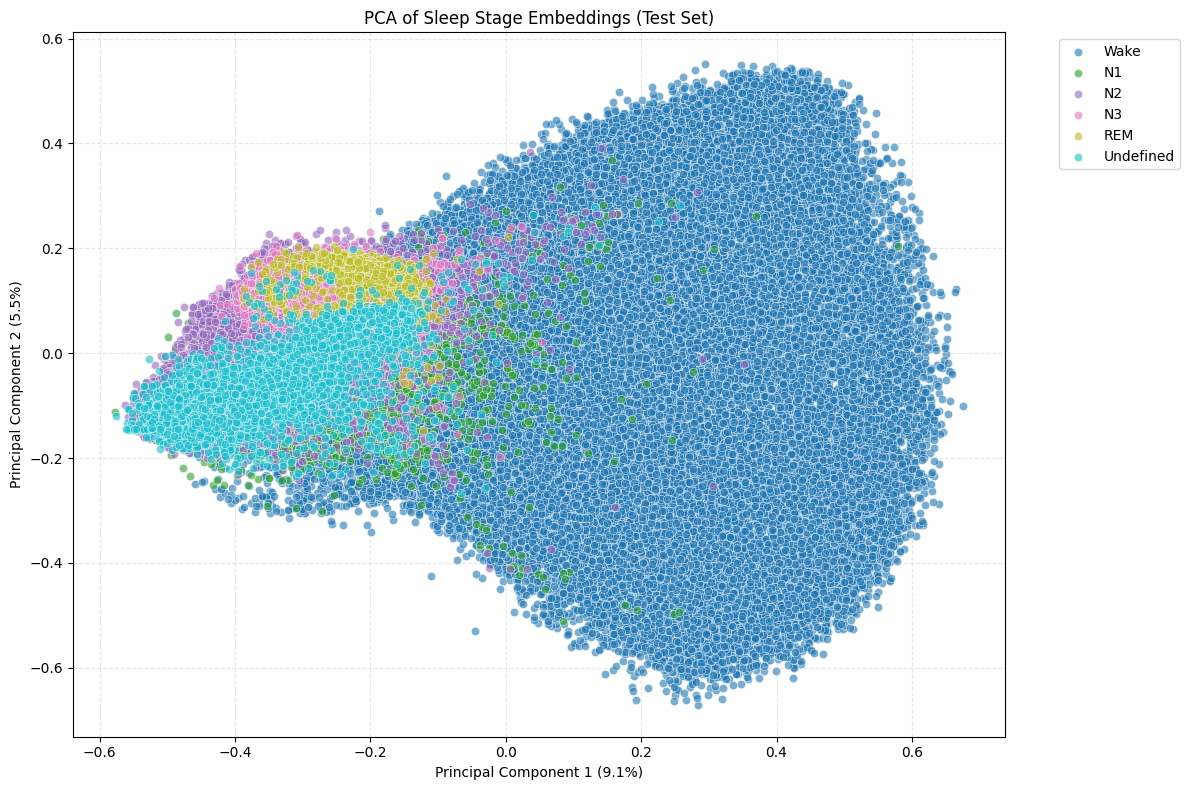

In [21]:
# ==========================================
# PCA Scatter Plot of Embeddings Colored by Labels
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Collect embeddings and labels from the test set
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        # Get normalized embeddings (512-dim)
        embeddings = model.get_embedding(inputs)  # shape: [batch, embedding_dim]
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)  # (N, 512)
labels = np.concatenate(all_labels, axis=0)          # (N,)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Unique labels in test set: {np.unique(labels)}")

# PCA to 2 components
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

# Define readable stage names (adjust if your label encoding differs)
stage_names = {
    0: 'Wake',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'REM',
    5: 'Undefined'   # or 'Unknown'
}

# Filter out any label not in stage_names (e.g., negative values)
valid_mask = np.isin(labels, list(stage_names.keys()))
embeddings_2d = embeddings_2d[valid_mask]
labels = labels[valid_mask]

# Create scatter plot
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(stage_names)))

for i, (stage, name) in enumerate(stage_names.items()):
    mask = (labels == stage)
    if np.sum(mask) == 0:
        continue
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                c=[colors[i]], label=name, alpha=0.6, edgecolors='w', linewidth=0.5)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA of Sleep Stage Embeddings (Test Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Embeddings shape: (87391, 512)
Unique labels in test set: [0 1 2 3 4 5]
Explained variance ratios:
  PC1: 0.091 (9.1%)
  PC2: 0.055 (5.5%)
  PC3: 0.045 (4.5%)


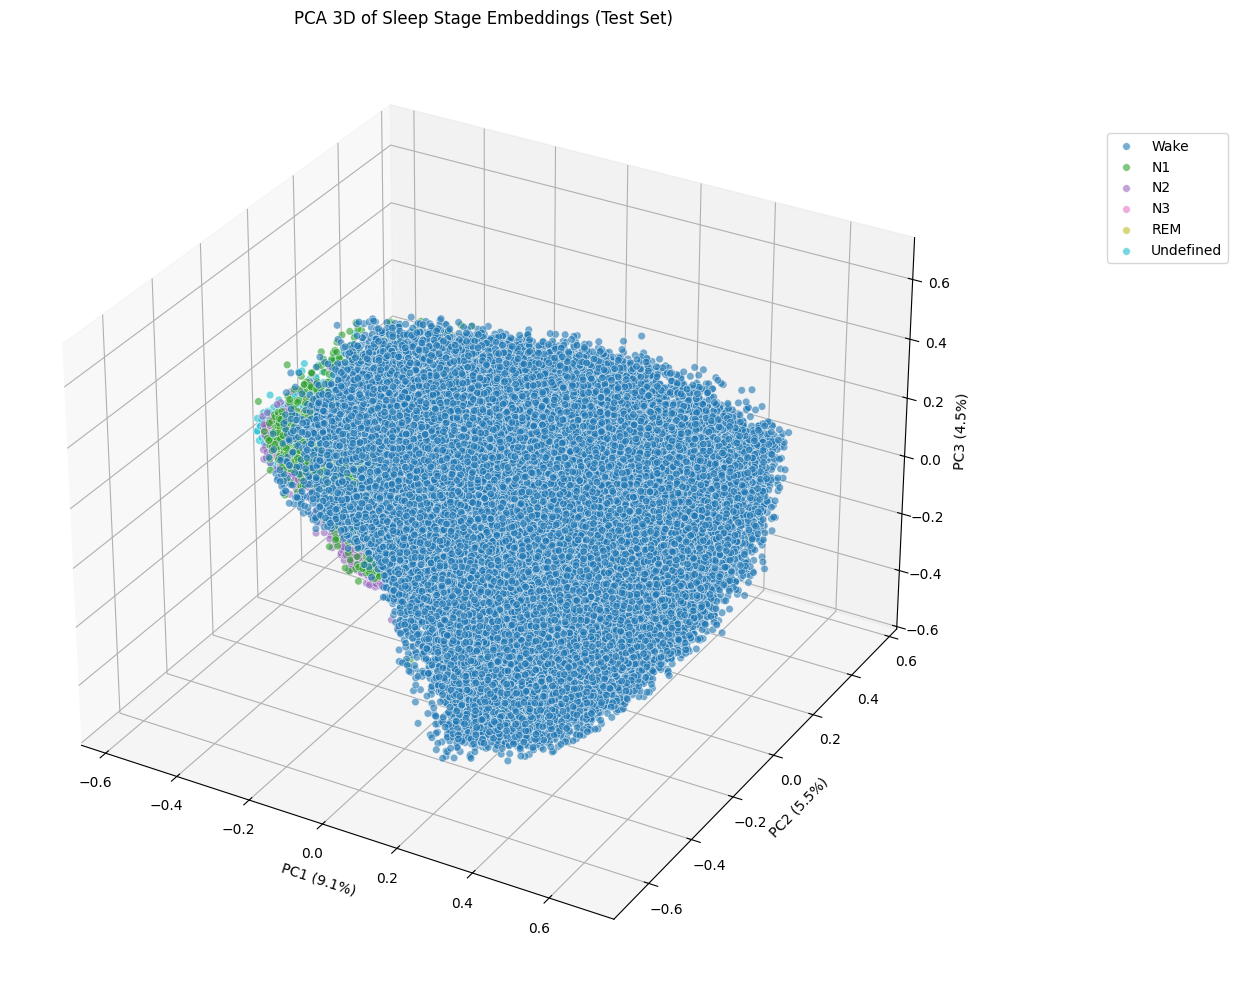

In [22]:
# ==========================================
# PCA 3D Scatter Plot of Embeddings Colored by Labels
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

# Collect embeddings and labels from the test set
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        embeddings = model.get_embedding(inputs)  # shape: [batch, embedding_dim]
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)  # (N, 512)
labels = np.concatenate(all_labels, axis=0)          # (N,)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Unique labels in test set: {np.unique(labels)}")

# PCA to 3 components
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)

print(f"Explained variance ratios:")
for i, ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ratio:.3f} ({ratio*100:.1f}%)")

# Define readable stage names (adjust if needed)
stage_names = {
    0: 'Wake',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'REM',
    5: 'Undefined'
}

# Filter out any label not in stage_names
valid_mask = np.isin(labels, list(stage_names.keys()))
embeddings_3d = embeddings_3d[valid_mask]
labels = labels[valid_mask]

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, len(stage_names)))

for i, (stage, name) in enumerate(stage_names.items()):
    mask = (labels == stage)
    if np.sum(mask) == 0:
        continue
    ax.scatter(embeddings_3d[mask, 0], 
               embeddings_3d[mask, 1], 
               embeddings_3d[mask, 2],
               c=[colors[i]], label=name, alpha=0.6, 
               edgecolors='w', linewidth=0.5, s=30)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA 3D of Sleep Stage Embeddings (Test Set)')

# Legend (placed outside to avoid clutter)
ax.legend(bbox_to_anchor=(1.15, 0.9), loc='upper left')

plt.tight_layout()
plt.show()